# ex-3 — pathwise formula (3.1), mono, composed on `fl_plot` (modern API remake)

The ex-3 figure set rebuilt from `fl_plot` marks only. Same three pathwise differences,
now as `Row(BoxDist)` compositions under `grid` — mono treatment first, then a
component-colored section (out-of-subspace blue) at the end. Composition-only: loads the
shared `ex2v2_df_{p,n}.parquet` cache (same spec as ex-2 v2); regenerate it there if
missing. Figures → `nb_outputs/mono-ex3-flplot/`.

Columns compared, per replicate:

- **left** — observable floor estimate $\hat\delta^2/(n\hat\lambda_{n,j}+\hat\delta^2)$
- **middle** — theoretical floor $\delta^2/(n\lambda_{n,j}+\delta^2)$
- **arg** — measured out-of-subspace mass $\Vert\Pi^{\perp}h_j\Vert^2$

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fl_plot.py").exists():
    REPO_ROOT = REPO_ROOT.parent          # notebook lives in mono/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import grid, Row, BandStack, BoxDist, Theme, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "mono" / "nb_outputs" / "ex3-flplot"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6, factor_cmaps=("Greys",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if not (_pq_p.exists() and _pq_n.exists()):
    raise RuntimeError("ex2v2 sweep cache missing — run ex-2_heavy_tail_v2 (root) or "
                       "mono/ex-2_heavy_tail_v2_mono first to regenerate it.")


def derive(df):
    left = df["observable_floor_estimate"]
    middle = df["floor"]
    arg = df["measured_out_of_subspace"]
    return df.assign(
        diff_left_middle=left - middle,   # observable estimate − theoretical floor
        diff_arg_left=arg - left,         # measured − observable estimate
        diff_middle_arg=middle - arg,     # theoretical floor − measured
        diff_left_arg=left - arg,         # observable estimate − measured
        diff_arg_middle=arg - middle,     # measured − theoretical floor
        ratio_ell_theta=(df["ell_bulk_eigenvalue_average"]
                         / df["theta_j_sample_eigenvalue"]),  # pathwise ℓ̂/θ̂
    )


df_p, df_n = derive(pd.read_parquet(_pq_p)), derive(pd.read_parquet(_pq_n))
_SWEEPS = [(df_p, "p", "growing p, fixed n=63"), (df_n, "n", "growing n, fixed p=3000")]

for d, key, lab in _SWEEPS:
    print(f"{lab}: {int(d['rep'].max()) + 1} reps × {d[key].nunique()} {key}-values "
          f"× {d['j'].nunique()} factors")

growing p, fixed n=63: 1000 reps × 6 p-values × 3 factors
growing n, fixed p=3000: 1000 reps × 9 n-values × 3 factors


## Decomposition bands (context)

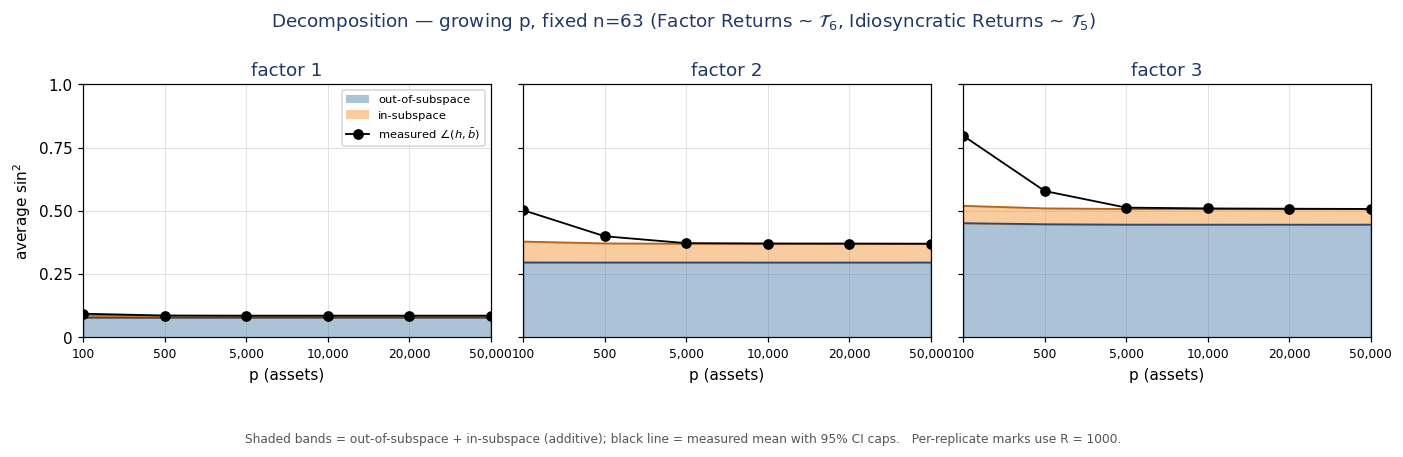

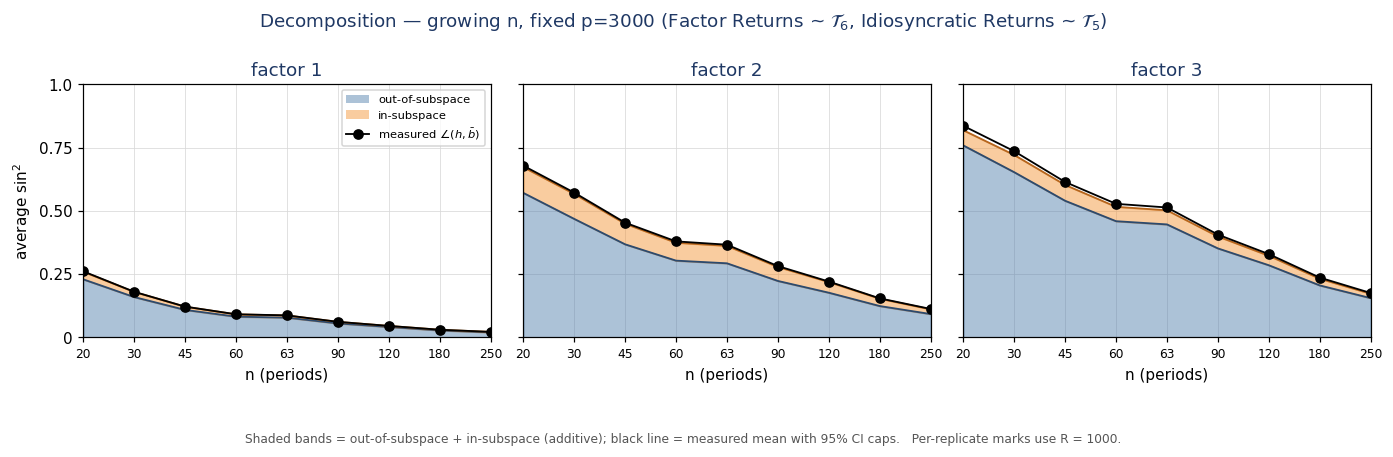

In [2]:
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0)],
        theme=MONO_THEME,
        suptitle=f"Decomposition — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_bands_{key}"))
    show(fig)

## Pathwise differences — three-row grid

All rows are oriented estimate − "truth".

Row 1: left − middle (observable floor estimate − theoretical floor).
Row 2: left − arg (observable estimate − measured; what formula (3.1) bounds).
Row 3: middle − arg (theoretical floor − measured).

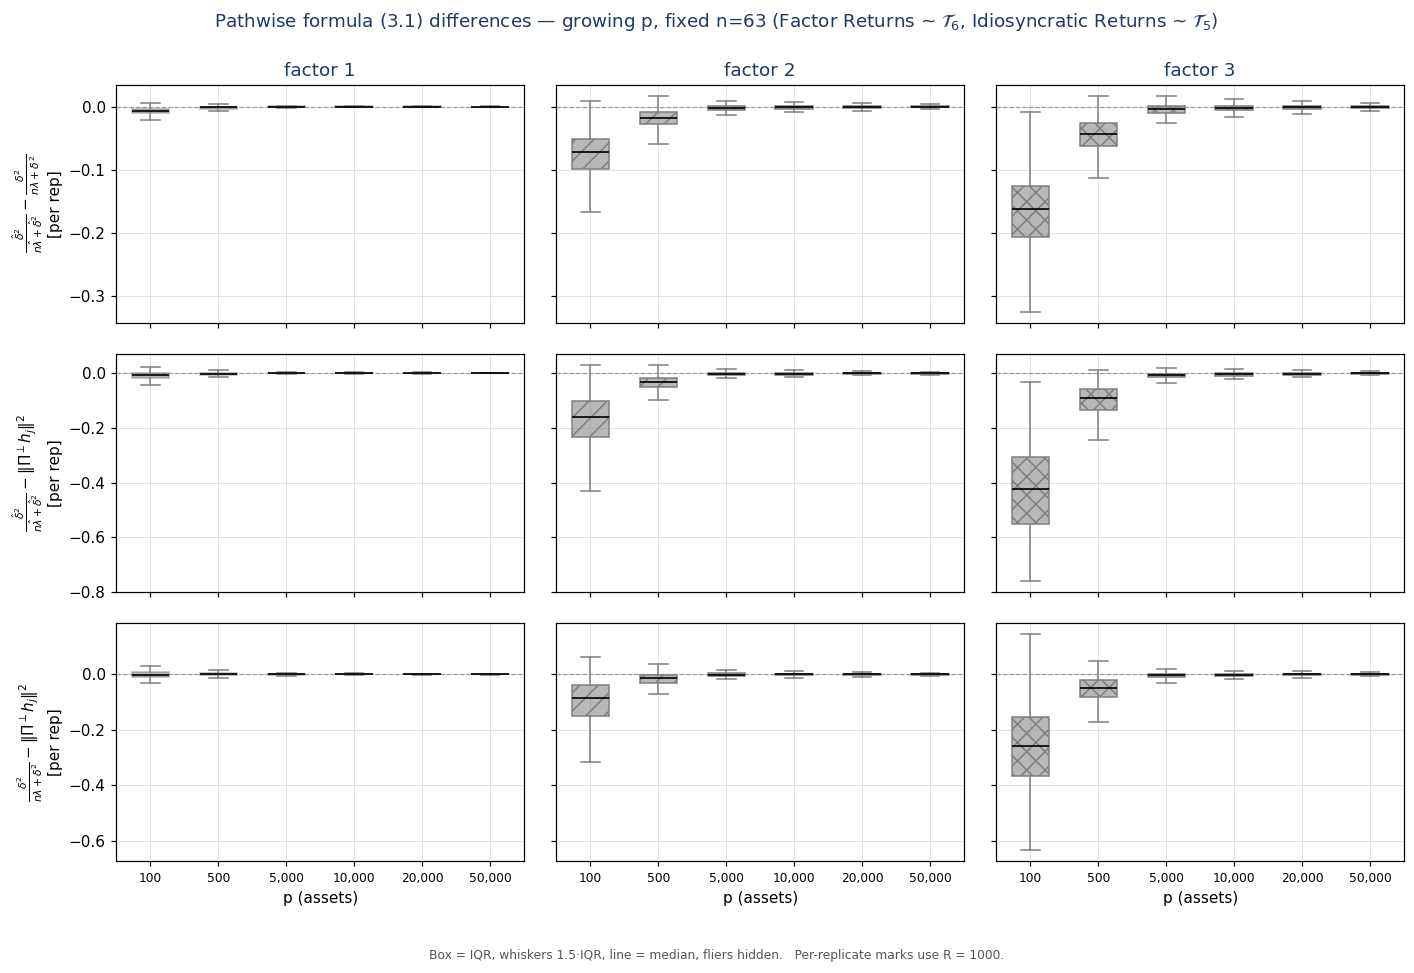

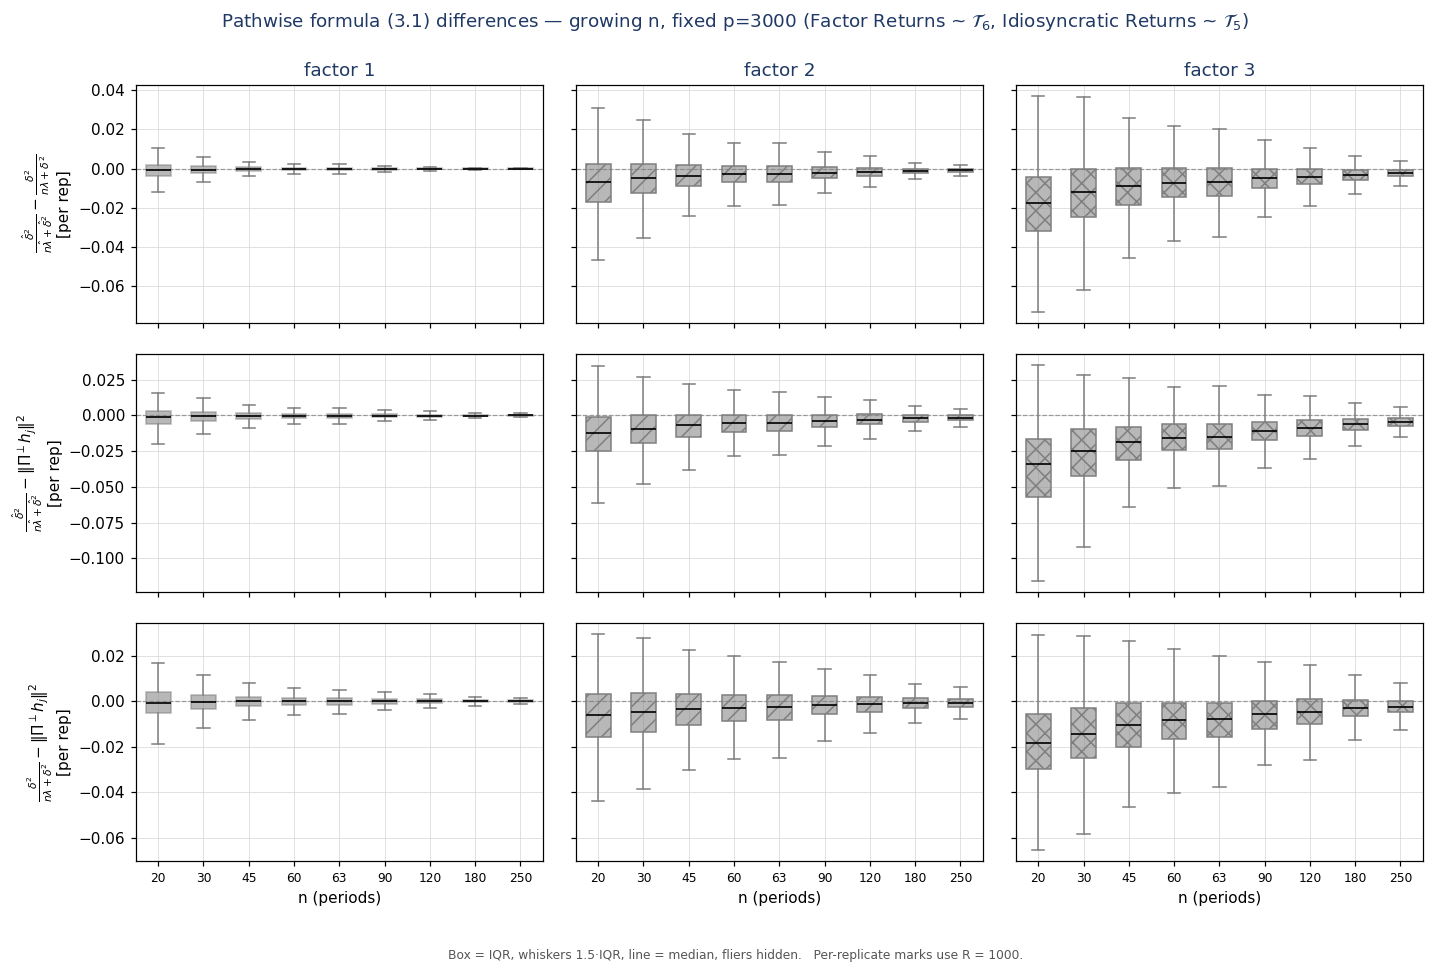

In [3]:
_ROWS3 = [
    Row(BoxDist("diff_left_middle"),
        ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
               " - \\frac{\\delta^2}{n\\lambda+\\delta^2}$\n[per rep]"),
    Row(BoxDist("diff_left_arg"),
        ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
               " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
    Row(BoxDist("diff_middle_arg"),
        ylabel="$\\frac{\\delta^2}{n\\lambda+\\delta^2}"
               " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
]
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key, rows=_ROWS3, theme=MONO_THEME,
        suptitle=f"Pathwise formula (3.1) differences — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid3_{key}"))
    show(fig)

## Two-row variant (shared y)

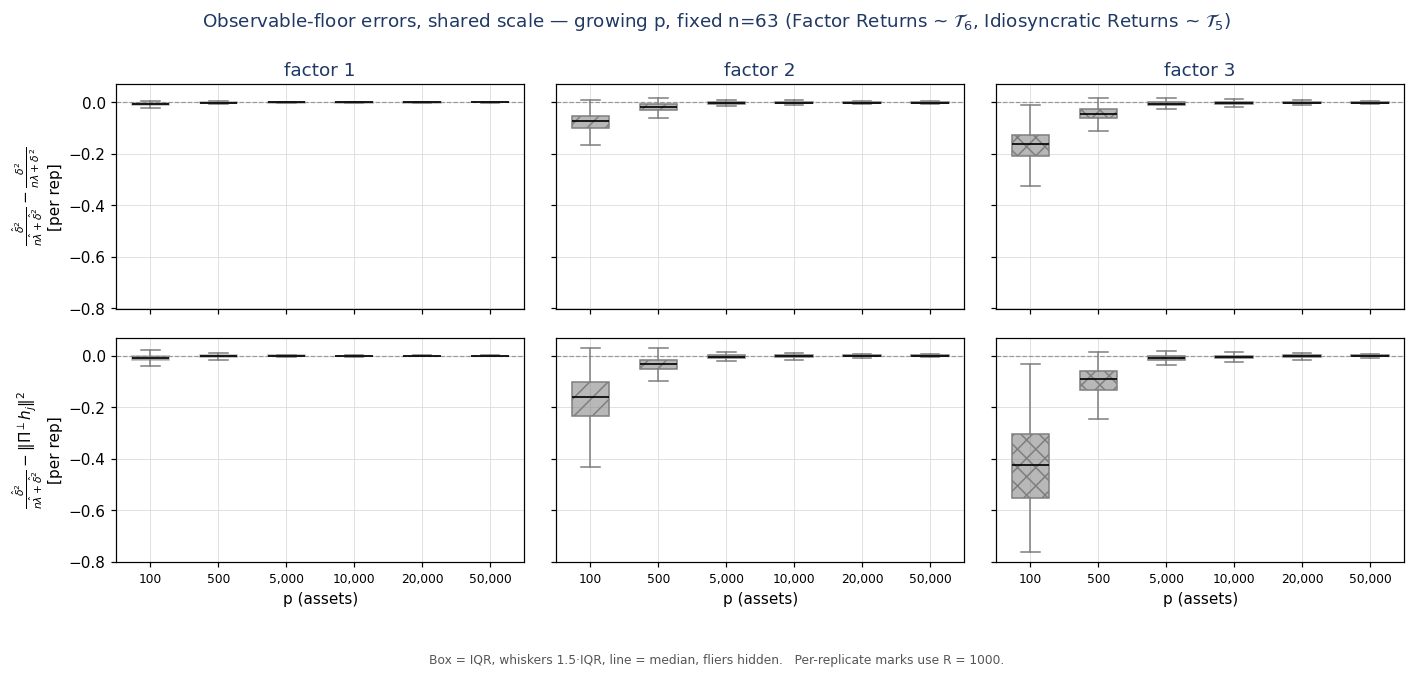

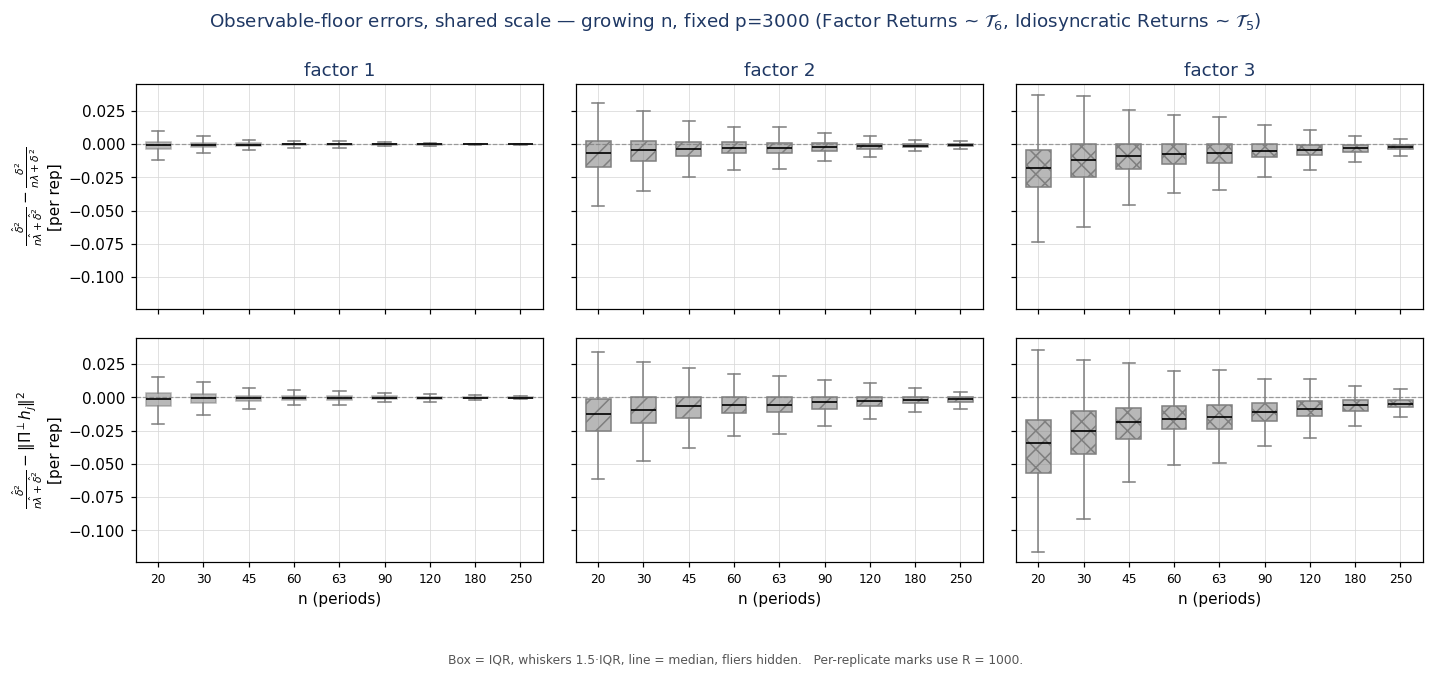

In [4]:
_ROWS2 = [
    Row(BoxDist("diff_left_middle"),
        ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
               " - \\frac{\\delta^2}{n\\lambda+\\delta^2}$\n[per rep]"),
    Row(BoxDist("diff_left_arg"),
        ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
               " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
]
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key, rows=_ROWS2, sharey=True, theme=MONO_THEME,
        suptitle=f"Observable-floor errors, shared scale — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid2_{key}"))
    show(fig)

## Single difference: observable estimate − measured

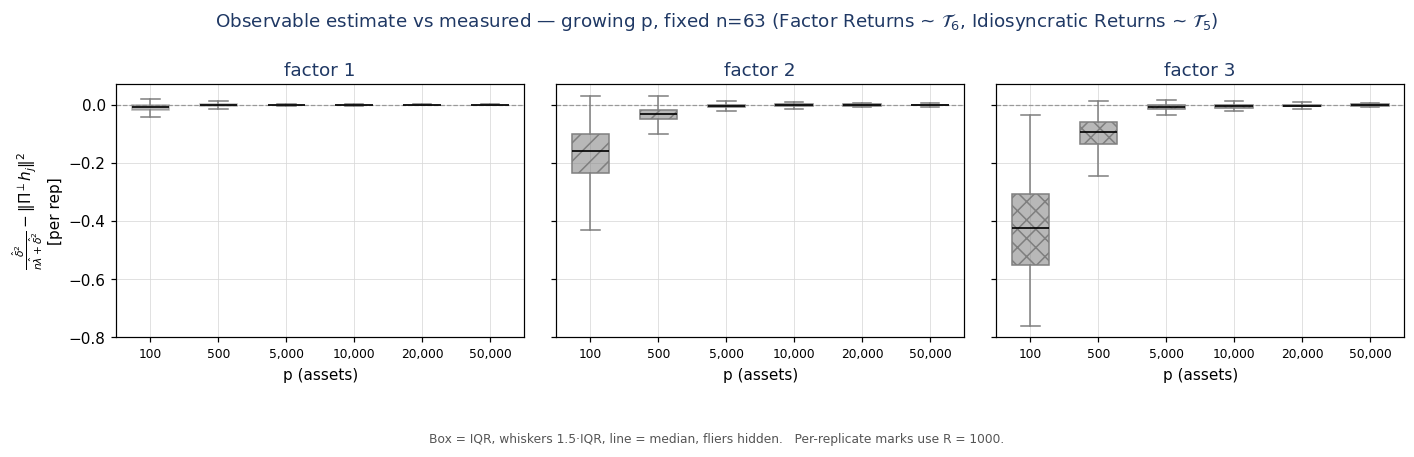

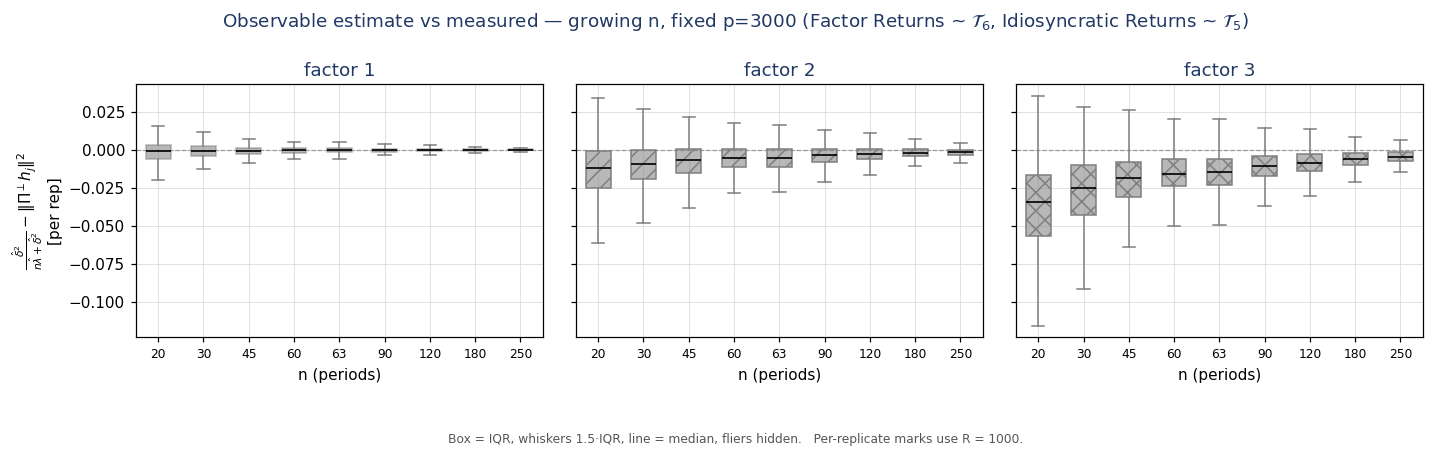

In [5]:
_ROWS1 = [Row(BoxDist("diff_left_arg"),
              ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
                     " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]", height=1.0)]
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key, rows=_ROWS1, sharey=True, theme=MONO_THEME,
        suptitle=f"Observable estimate vs measured — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid1_{key}"))
    show(fig)

## Summary numbers

In [6]:
def summary(d, key):
    g = d.groupby([key, "j"])
    out = g[["diff_left_middle", "diff_left_arg", "diff_middle_arg"]].median()
    out.columns = [f"med {c}" for c in out.columns]
    out["IQR diff_left_arg"] = (g["diff_left_arg"].quantile(0.75)
                                - g["diff_left_arg"].quantile(0.25))
    return out.round(4)

for d, key, lab in _SWEEPS:
    print(f"--- {lab} ---")
    display(summary(d, key))

--- growing p, fixed n=63 ---


med diff_left_middle  med diff_left_arg  med diff_middle_arg  \
p     j                                                                 
100   1               -0.0070            -0.0081              -0.0011   
      2               -0.0721            -0.1597              -0.0856   
      3               -0.1624            -0.4249              -0.2586   
500   1               -0.0013            -0.0016              -0.0001   
      2               -0.0179            -0.0318              -0.0151   
      3               -0.0433            -0.0922              -0.0490   
5000  1               -0.0002            -0.0002              -0.0000   
      2               -0.0017            -0.0033              -0.0013   
      3               -0.0042            -0.0087              -0.0046   
10000 1               -0.0001            -0.0001               0.0000   
      2               -0.0010            -0.0019              -0.0010   
      3               -0.0023            -0.0046              -0.0022   
20000 1               -0.0000            -0.0001              -0.0000   
      2               -0.0004            -0.0009              -0.0005   
      3               -0.0012            -0.0024              -0.0010   
50000 1               -0.0000            -0.0000              -0.0000   
      2               -0.0002            -0.0003              -0.0002   
      3               -0.0004            -0.0008              -0.0004   

         IQR diff_left_arg  
p     j                     
100   1             0.0164  
      2             0.1339  
      3             0.2462  
500   1             0.0072  
      2             0.0325  
      3             0.0744  
5000  1             0.0024  
      2             0.0086  
      3             0.0140  
10000 1             0.0017  
      2             0.0065  
      3             0.0094  
20000 1             0.0011  
      2             0.0040  
      3             0.0065  
50000 1             0.0007  
      2             0.0029  
      3             0.0039

--- growing n, fixed p=3000 ---


med diff_left_middle  med diff_left_arg  med diff_middle_arg  \
n   j                                                                 
20  1               -0.0009            -0.0011              -0.0007   
    2               -0.0068            -0.0123              -0.0059   
    3               -0.0177            -0.0343              -0.0182   
30  1               -0.0005            -0.0006              -0.0002   
    2               -0.0048            -0.0092              -0.0049   
    3               -0.0117            -0.0250              -0.0143   
45  1               -0.0003            -0.0005              -0.0001   
    2               -0.0036            -0.0067              -0.0034   
    3               -0.0087            -0.0187              -0.0104   
60  1               -0.0002            -0.0003              -0.0001   
    2               -0.0029            -0.0056              -0.0029   
    3               -0.0073            -0.0159              -0.0082   
63  1               -0.0002            -0.0004              -0.0002   
    2               -0.0026            -0.0054              -0.0028   
    3               -0.0069            -0.0148              -0.0080   
90  1               -0.0001            -0.0002               0.0000   
    2               -0.0021            -0.0037              -0.0016   
    3               -0.0050            -0.0108              -0.0057   
120 1               -0.0001            -0.0002              -0.0000   
    2               -0.0016            -0.0029              -0.0013   
    3               -0.0041            -0.0086              -0.0046   
180 1               -0.0001            -0.0001              -0.0000   
    2               -0.0011            -0.0020              -0.0010   
    3               -0.0030            -0.0060              -0.0030   
250 1               -0.0000            -0.0001              -0.0000   
    2               -0.0008            -0.0015              -0.0007   
    3               -0.0022            -0.0047              -0.0025   

       IQR diff_left_arg  
n   j                     
20  1             0.0093  
    2             0.0244  
    3             0.0404  
30  1             0.0064  
    2             0.0193  
    3             0.0328  
45  1             0.0040  
    2             0.0155  
    3             0.0231  
60  1             0.0028  
    2             0.0118  
    3             0.0180  
63  1             0.0027  
    2             0.0113  
    3             0.0176  
90  1             0.0020  
    2             0.0087  
    3             0.0131  
120 1             0.0015  
    2             0.0069  
    3             0.0112  
180 1             0.0010  
    2             0.0045  
    3             0.0078  
250 1             0.0007  
    2             0.0034  
    3             0.0056

---
## Component-colored versions

All differences here are out-of-subspace quantities, so the whole section uses the
out-of-subspace blue from the component palette.

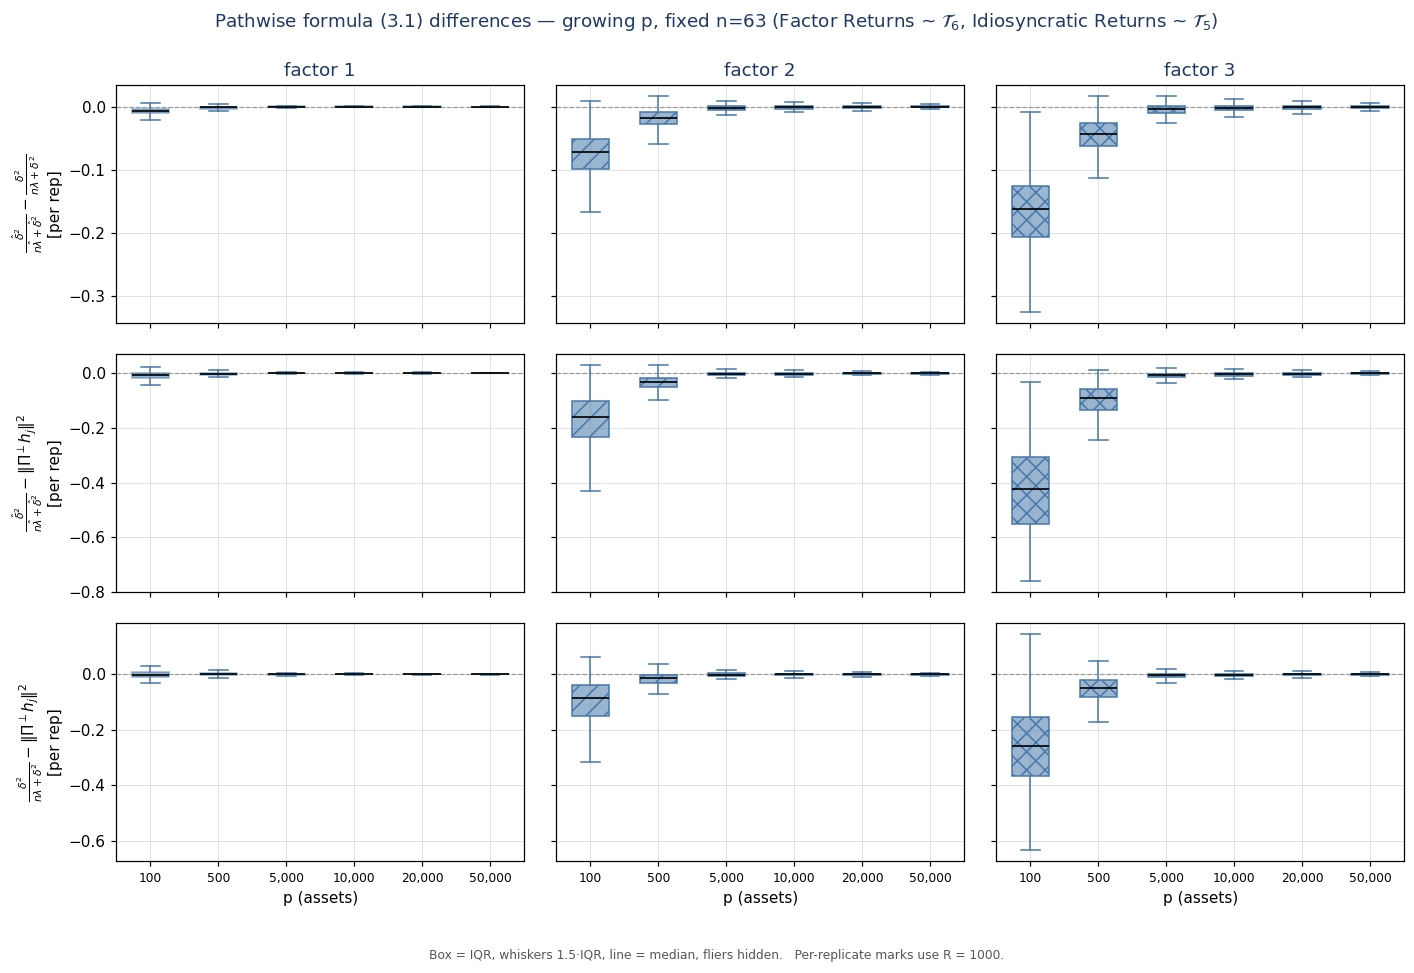

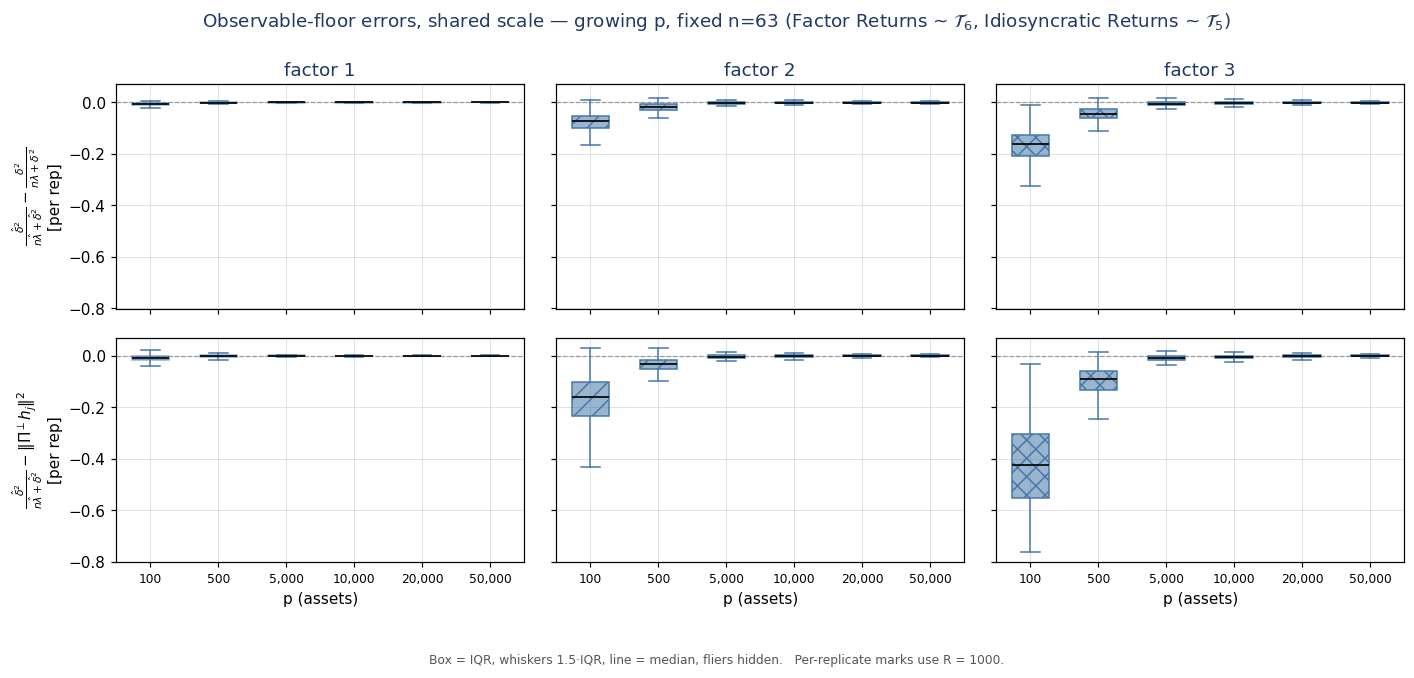

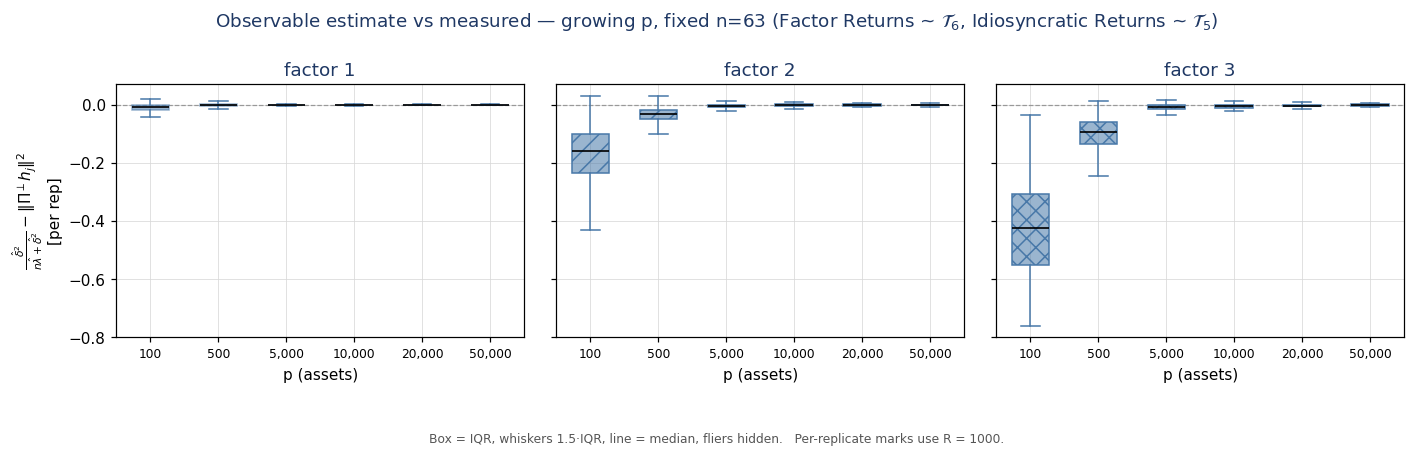

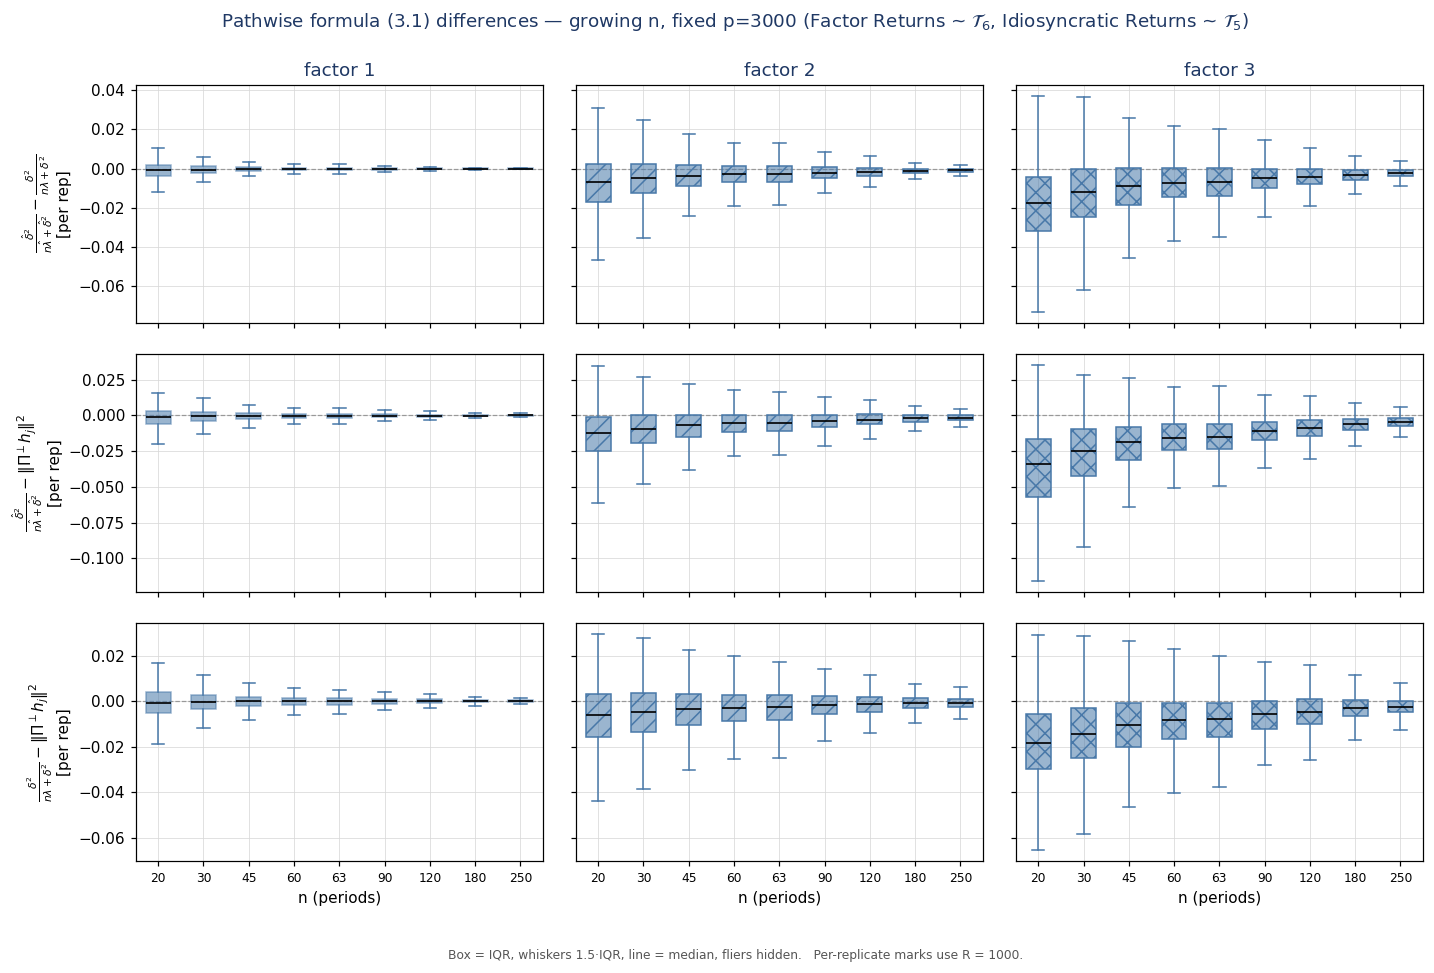

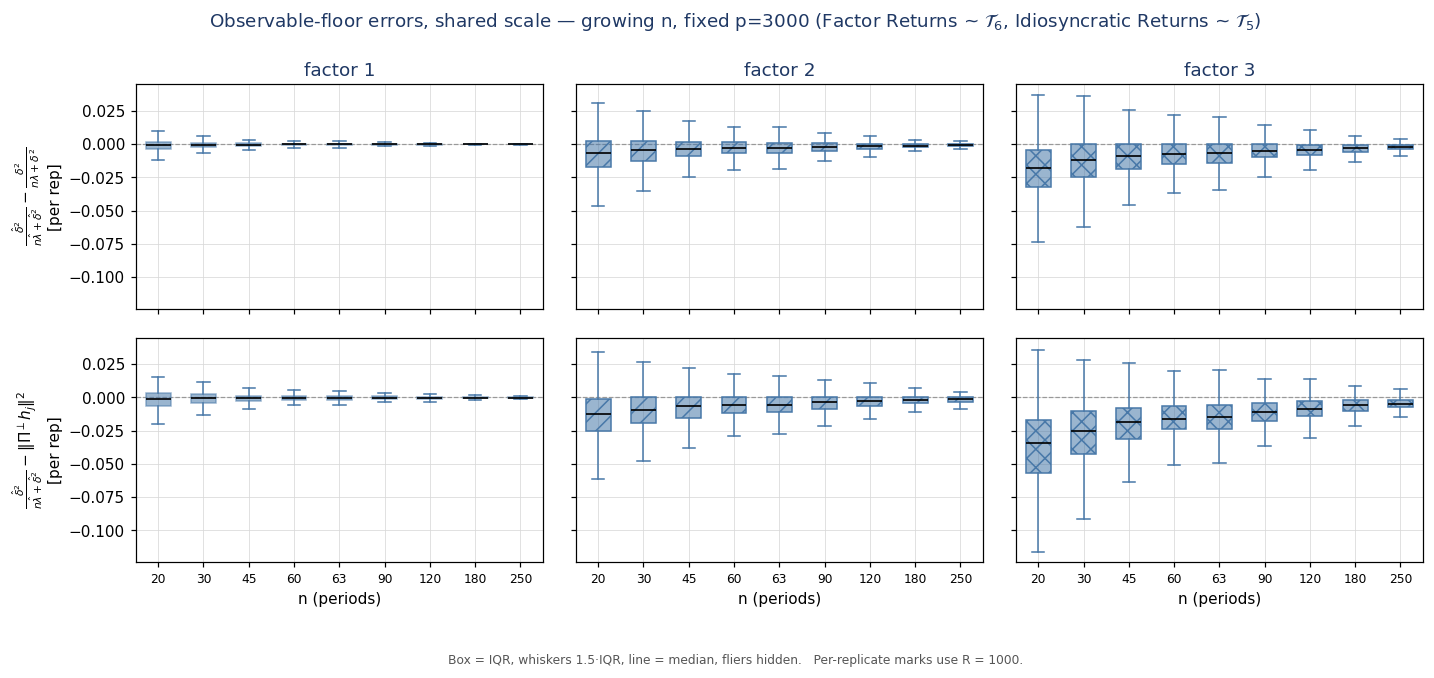

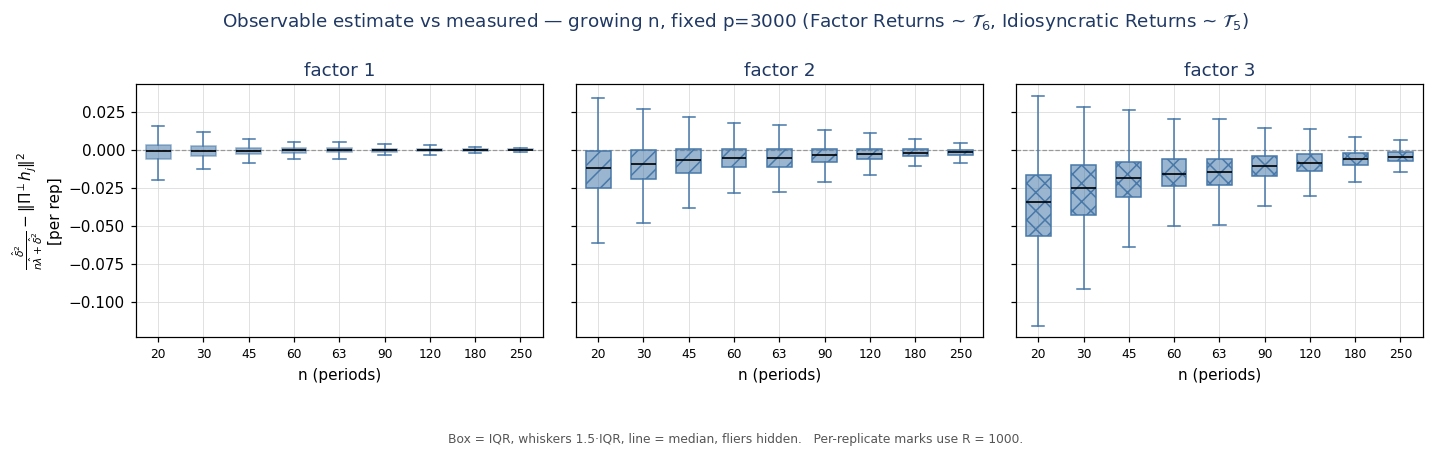

In [7]:
OOS_T = Theme(factor_colors=("#4878a8",) * 6, factor_cmaps=("Blues",) * 6,
              factor_hatches=FACTOR_HATCHES,
              ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))

for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key, rows=_ROWS3, theme=OOS_T,
        suptitle=f"Pathwise formula (3.1) differences — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid3_{key}_qcolor"))
    show(fig)
    fig, _ = grid(d, key, rows=_ROWS2, sharey=True, theme=OOS_T,
        suptitle=f"Observable-floor errors, shared scale — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid2_{key}_qcolor"))
    show(fig)
    fig, _ = grid(d, key, rows=_ROWS1, sharey=True, theme=OOS_T,
        suptitle=f"Observable estimate vs measured — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex3_grid1_{key}_qcolor"))
    show(fig)

---
## Out-of-subspace levels over the growing-p boxplots

Top row: the ex-2 out-of-subspace top row, verbatim — theoretical floor
$\delta^2/(n\lambda_{n,j}+\delta^2)$ (band) and measured $\Vert\Pi^{\perp}h_j\Vert^2$
(dots, mean across reps), plus the mean pathwise ratio $\hat\ell/\hat\theta_j$ in red.
Bottom row: the same growing-p observable-estimate − measured boxplots as the
single-difference figure above.

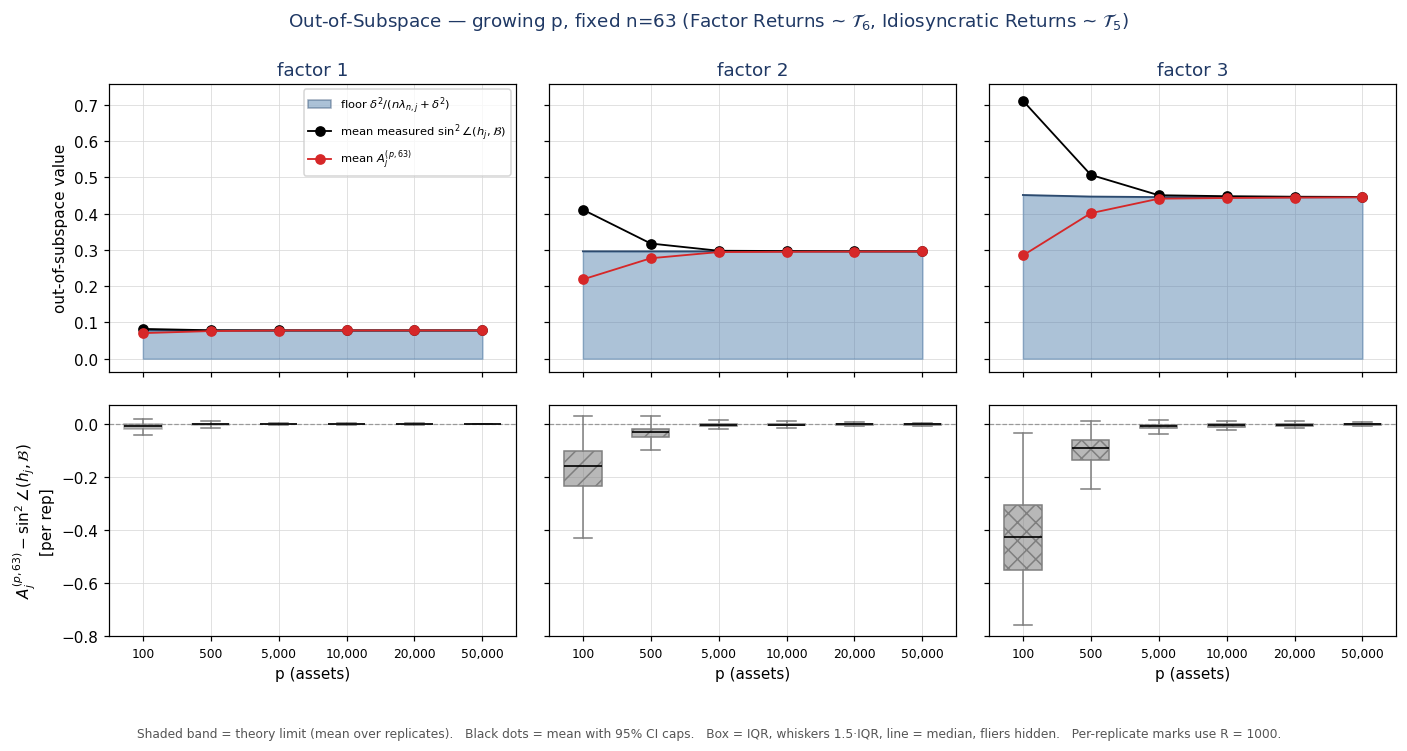

In [8]:
from fl_plot import Band, MeanCI

fig, _ = grid(df_p, "p",
    rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
               MeanCI("measured_out_of_subspace",
                    #   label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                    label=r"mean measured $\sin^2\angle(h_j,\mathcal{B})$"),
               MeanCI("ratio_ell_theta", 
                    #   label=r"mean $\hat\ell/\hat\theta_j$",
                    label=r"mean $A_j^{(p,63)}$",
                      color="tab:red",
                    #   caption=r"red dots = mean $\hat\ell/\hat\theta_j$ over replicates")],
                    )],
            #   ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
            ylabel=r"out-of-subspace value", height=1.0),
          Row(BoxDist("diff_left_arg"),
              ylabel="$A_j^{(p,63)} - \\sin^2\\angle(h_j,\\mathcal{B})$\n[per rep]")],
                    #  " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]")],
    theme=MONO_THEME,
    suptitle=f"Out-of-Subspace — growing p, fixed n=63 {_TAILS}",
    formats=FIG_FORMATS, out_path=out("ex3_oos_levels_p", save=True))
show(fig)

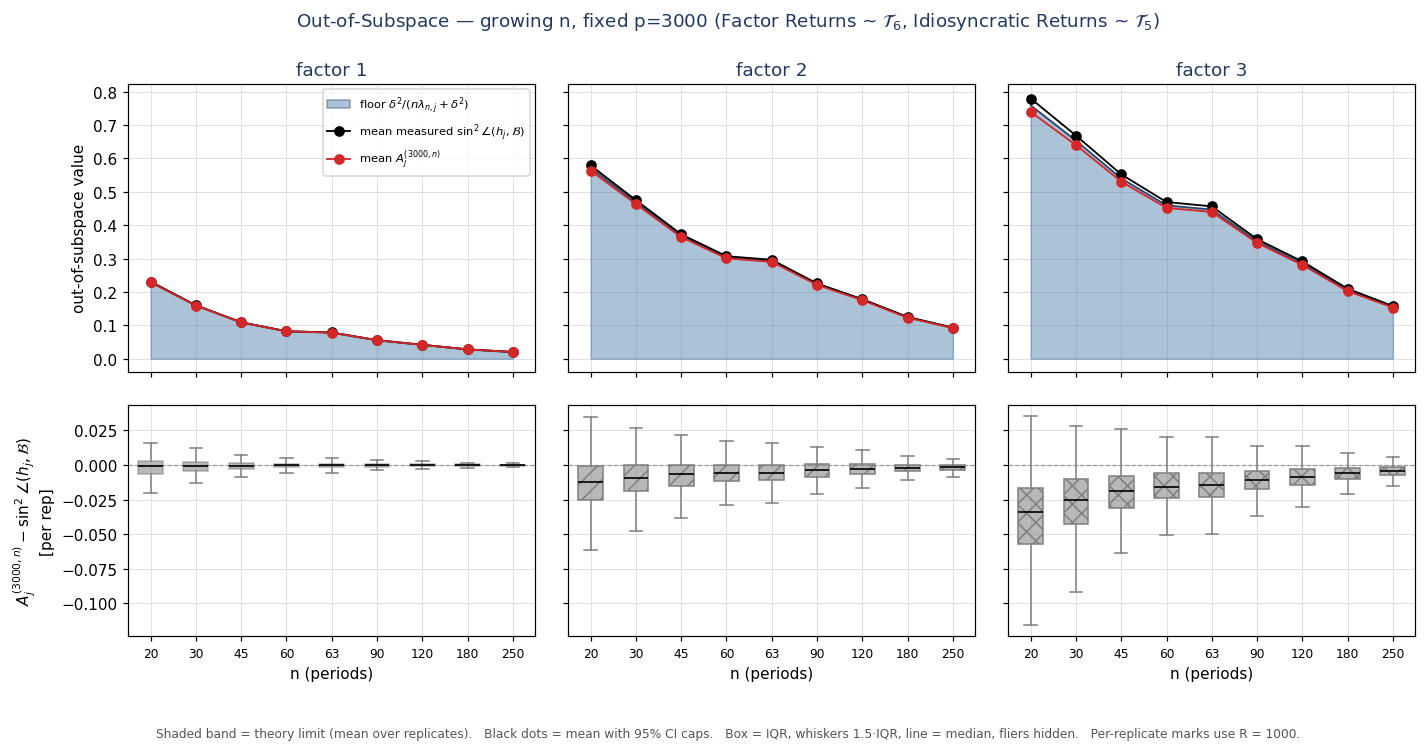

In [9]:
from fl_plot import Band, MeanCI

fig, _ = grid(df_n, "n",
    rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
               MeanCI("measured_out_of_subspace",
                    #   label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                    label=r"mean measured $\sin^2\angle(h_j,\mathcal{B})$"),
               MeanCI("ratio_ell_theta", 
                    #   label=r"mean $\hat\ell/\hat\theta_j$",
                    label=r"mean $A_j^{(3000,n)}$",
                      color="tab:red",
                    #   caption=r"red dots = mean $\hat\ell/\hat\theta_j$ over replicates")],
                    )],
            #   ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
            ylabel=r"out-of-subspace value", height=1.0),
          Row(BoxDist("diff_left_arg"),
              ylabel="$A_j^{(3000,n)} - \\sin^2\\angle(h_j,\\mathcal{B})$\n[per rep]")],
                    #  " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]")],
    theme=MONO_THEME,
    suptitle=f"Out-of-Subspace — growing n, fixed p=3000 {_TAILS}",
    formats=FIG_FORMATS, out_path=out("ex3_oos_levels_n", save=True))
show(fig)

---
## Change log

- **2026-08-13**: modern-API remake of the mono ex-3 figure set — every figure composed
  from `fl_plot` marks (`BandStack`/`BoxDist` rows under `grid`), mono +
  component-colored sections. Composition-only: data from the shared ex2v2 cache.
- **2026-08-13**: gray boxes with per-factor hatching; new bottom figure — out-of-subspace levels (observable estimate band + measured mean) over the growing-p difference boxplots.
